In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [14]:
import zipfile

zip_ref = zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip', 'r')
zip_ref.extractall('/content/brain_tumor_data')
zip_ref.close()

In [15]:
# to load the images...
# we are using generators
# generators are very usefulltoprocess large amount o data, it took thedata in batches instead of loading all at once...
# so genertor is there in keras "image_dataset_from_directory"

#load data
import tensorflow as tf

train_ds=tf.keras.utils.image_dataset_from_directory(
    directory='/content/brain_tumor_data/Training',
    labels='inferred', # tells keras to figure out the number of classs labels automaticaslly from the folder strurcture
    label_mode='categorical', # controls how those classes got labeled so int means each gets assigned as 0 , 1 2 ,3 , if we cateogroical the ohe happens and binray for 2 class classification
    validation_split=0.15, # tajkes 15% out of training data menas i ma telling split the data in 15%
    subset='training',        # this call returns the 85% training portion
    seed=42,                  # must match val_ds seed so the split is consistent
    batch_size=32, # instead of loding entire dataset at once it will load in batches as 32
    color_mode='grayscale',
    image_size=(256,256) # Every image gets resized to 256x256 pixels on load
    )

val_ds=tf.keras.utils.image_dataset_from_directory(
    directory='/content/brain_tumor_data/Training',
    labels='inferred',
    label_mode='categorical',
    validation_split=0.15,
    subset='validation',
    seed=42,
    batch_size=32,
    color_mode='grayscale',
    image_size=(256,256)
    )

test_ds=tf.keras.utils.image_dataset_from_directory(
    directory='/content/brain_tumor_data/Testing',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    color_mode='grayscale',
    image_size=(256,256)
    )

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.


In [16]:
# normalization

def process(image,label):
    image = tf.cast(image/255., tf.float32)
    return image,label

train_ds=train_ds.map(process)
val_ds=val_ds.map(process)
test_ds=test_ds.map(process)

In [17]:
!pip install keras-tuner

In [18]:
# create cnn model now
import keras_tuner as kt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.metrics import Recall, Precision

def build_model(hp):
  model=Sequential()

  counter=0
  for i in range(hp.Int('layers',min_value=1,max_value=8)):
    if counter==0:
      model.add(Conv2D(
          hp.Int("neurons"+str(i),min_value=8,max_value=128,step=8),
          activation='relu',
          kernel_size=(3,3),
          padding=hp.Choice("padding"+str(i),values=['valid','same']),
          input_shape=(256,256,1)
      ))
      model.add(MaxPooling2D(pool_size=(2,2)))
    else:
      model.add(Conv2D(
          hp.Int("neurons"+str(i),min_value=8,max_value=128,step=8),
          activation='relu',
          kernel_size=(3,3),
          padding=hp.Choice("padding"+str(i),values=['valid','same'])
      ))
      model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Dropout(
        hp.Float(
                    'dropout_' + str(i),
                    min_value=0.0,
                    max_value=0.5,
                    step=0.1
                )
    ))

    counter += 1

  model.add(Flatten())

  model.add(Dense(
        hp.Int("neurons",min_value=8,max_value=128,step=8),
        activation=hp.Choice('activation',values=['relu','tanh','sigmoid'])
  ))


  model.add(Dense(4, activation='softmax'))

  model.compile(
        optimizer=hp.Choice(
            'optimizer',
            values=['adam', 'sgd', 'rmsprop', 'adagrad']
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]
    )

  return model

In [19]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_recall', direction='max'),
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='brain_tumor_cnn'
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_recall',
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Trial 10 Complete [00h 05m 01s]
val_recall: 0.7714285850524902

Best val_recall So Far: 0.9357143044471741
Total elapsed time: 00h 31m 41s


In [21]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [23]:
tuner.get_best_hyperparameters()[0].values

{'layers': 6,
 'neurons0': 88,
 'padding0': 'same',
 'dropout_0': 0.2,
 'neurons': 56,
 'activation': 'relu',
 'optimizer': 'adam',
 'neurons1': 80,
 'padding1': 'valid',
 'dropout_1': 0.1,
 'neurons2': 24,
 'padding2': 'valid',
 'dropout_2': 0.2,
 'neurons3': 80,
 'padding3': 'valid',
 'dropout_3': 0.30000000000000004,
 'neurons4': 72,
 'padding4': 'same',
 'dropout_4': 0.0,
 'neurons5': 112,
 'padding5': 'same',
 'dropout_5': 0.2,
 'neurons6': 56,
 'padding6': 'same',
 'dropout_6': 0.4,
 'neurons7': 32,
 'padding7': 'same'}

In [24]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 88)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 88)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 88)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 80)   │        63,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 24)     │        17,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 80)     │        17,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 72)     │        51,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 72)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 72)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 112)      │        72,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 112)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 112)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 56)             │        56,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           228 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,316 (1.07 MB)

 Trainable params: 280,316 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
tuner.results_summary()

Results summary
Results in tuner_dir/brain_tumor_cnn
Showing 10 best trials
Objective(name="val_recall", direction="max")

Trial 08 summary
Hyperparameters:
layers: 6
neurons0: 88
padding0: same
dropout_0: 0.2
neurons: 56
activation: relu
optimizer: adam
neurons1: 80
padding1: valid
dropout_1: 0.1
neurons2: 24
padding2: valid
dropout_2: 0.2
neurons3: 80
padding3: valid
dropout_3: 0.30000000000000004
neurons4: 72
padding4: same
dropout_4: 0.0
neurons5: 112
padding5: same
dropout_5: 0.2
neurons6: 56
padding6: same
dropout_6: 0.4
neurons7: 32
padding7: same
Score: 0.9357143044471741

Trial 05 summary
Hyperparameters:
layers: 1
neurons0: 24
padding0: valid
dropout_0: 0.0
neurons: 120
activation: sigmoid
optimizer: adam
neurons1: 16
padding1: valid
dropout_1: 0.1
neurons2: 40
padding2: same
dropout_2: 0.0
neurons3: 128
padding3: valid
dropout_3: 0.4
neurons4: 72
padding4: valid
dropout_4: 0.2
neurons5: 40
padding5: valid
dropout_5: 0.1
Score: 0.9321428537368774

Trial 00 summary
Hyperparame

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_recall', mode='max', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_recall', mode='max', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.9595 - loss: 0.1135 - precision: 0.9610 - recall: 0.9574 - val_accuracy: 0.9476 - val_loss: 0.1550 - val_precision: 0.9498 - val_recall: 0.9464 - learning_rate: 0.0010
Epoch 2/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 144ms/step - accuracy: 0.9672 - loss: 0.0898 - precision: 0.9684 - recall: 0.9672 - val_accuracy: 0.9393 - val_loss: 0.2232 - val_precision: 0.9437 - val_recall: 0.9381 - learning_rate: 0.0010
Epoch 3/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9670 - loss: 0.0920 - precision: 0.9678 - recall: 0.9662 - val_accuracy: 0.9476 - val_loss: 0.1652 - val_precision: 0.9532 - val_recall: 0.9464 - learning_rate: 0.0010
Epoch 4/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.9708 - loss: 0.0763 - precision: 0.9718 - recall: 0.9706 - val_accuracy: 0.9429 - val_loss: 0.1855 - val_precision: 0.9440 - val_recall: 0.9429 - learning_rate: 0.0010
Epoch 5/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/st

In [31]:
results = model.evaluate(test_ds)
print(results)   # see the order first

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9156 - loss: 1.0661 - precision: 0.9167 - recall: 0.9150
[1.0660500526428223, 0.9156249761581421, 0.9150000214576721, 0.9167188405990601]


In [32]:
test_loss, test_acc, test_recall, test_precision = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test Precision: {test_precision:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9156 - loss: 1.0660 - precision: 0.9167 - recall: 0.9150
Test Loss: 1.0660
Test Accuracy: 0.9156
Test Recall: 0.9150
Test Precision: 0.9167


In [163]:
# test on real data...

from PIL import Image

img=Image.open("/content/brain3.jpg").convert("L")



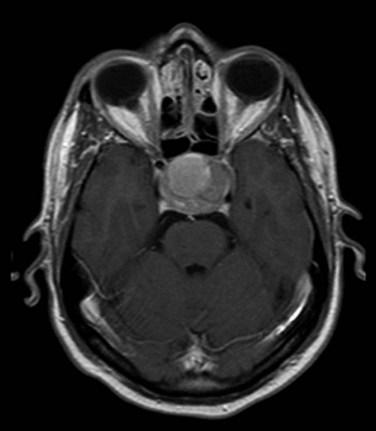

In [164]:
img

In [165]:
# resize

img=img.resize((256,256))

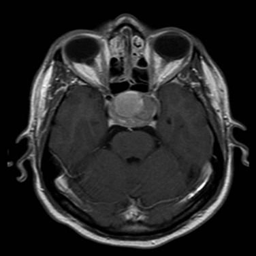

In [166]:
img

In [167]:
#numpy
import numpy as np
img=np.array(img)

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)
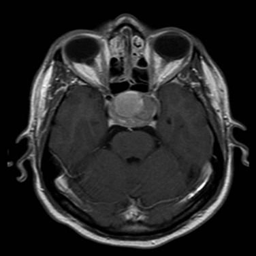

In [168]:
img

In [169]:
import os

class_names = sorted(os.listdir('/content/brain_tumor_data/Training'))
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [170]:
img = np.array(img) / 255.   # normalize, matching training
img = img.astype(np.float32)
img = img.reshape(1, 256, 256, 1)

prediction = model.predict(img)
predicted_class = class_names[np.argmax(prediction)]
print("Predicted:", predicted_class, "| Confidence:", np.max(prediction)*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: pituitary | Confidence: 99.99996


In [171]:
model.save('brain_tumor_model.keras')

In [172]:
from google.colab import files
files.download('brain_tumor_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>